# Relevant Papers
>Su, M.-C., & Liu, T.-K. (2001).  
>Application of neural networks using quadratic junctions in cluster analysis.  
>Neurocomputing, 37, 165 – 175. doi:10.1016/S0925-2312(00)00343-X.  

>Su, M.-C., & Liu, Y.-C. (2005).  
>A new approach to clustering data with arbitrary shapes.  
>Pattern Recognition, 38, 1887 – 1901. doi:10.1016/j.patcog.2005.04.010.  

# Import Necessary Libraries

In [4]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

from artlib import QuadraticNeuronART

# Dataset Generation
In this example we use sklearn to generate a synthetic dataset, This dataset contains continous-value features and target labels, making it suitable for probabilitistic clustering

`n_samples` = 150: The dataset will contain 150 samples (input vectors).  
`centers` = 3: The dataset is structured around 3 distinct cluster centers, representing the underlying true clusters.  
`cluster_std` = 0.50: This parameter controls the standard deviation of the clusters, set to 0.50 for relatively compact clusters with lower spread.  
`random_state` = 0: Ensures the reproducibility of the generated data, making results consistent across runs.  
`shuffle` = False: Keeps the original ordering of the samples, preserving the sequential arrangement of the data.

In [5]:
data, target = make_blobs(n_samples=150, centers=3, cluster_std=0.50, random_state=0, shuffle=False)
print("Data has shape:", data.shape)


Data has shape: (150, 2)


## Clustering with ART2
### TODO
In the example below, we initialize the ART2 model with specific parameters:

- `rho`: The vigilance parameter, controlling the level of similarity required for vectors to belong to the same cluster.
- `s_init`: Sets the intial spread of the quadratic junctions used for clustering
- `lr_b`: The learning rate for Bias
- `lr_w`: The learning rate for weights
- `lr_s`: The learning rate for spread

We prepare the data for input into the ART2 model using the `prepare_data` method, and then fit the model and predict cluster assignments with `fit_predict`.

After the clustering process, we can visualize the clusters using the `visualize` method.

Prepared data has shape: (150, 2)
3 clusters found


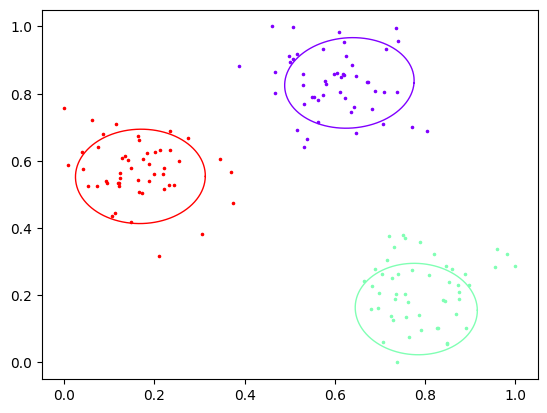

In [6]:
params = {
    "rho": 0.9,
    "s_init": 0.9,
    "lr_b": 0.1,
    "lr_w": 0.1,
    "lr_s": 0.1
}
cls = QuadraticNeuronART(**params)

X = cls.prepare_data(data)
print("Prepared data has shape:", X.shape)

y = cls.fit_predict(X)

print(f"{cls.n_clusters} clusters found")

cls.visualize(X, y)
plt.show()
